# Eksperyment 3: Wizualizacja mechanizmu uwagi (Attention Maps)

**Przedmiot:** ADOM  
**Metoda:** Show, Attend and Tell - automatyczne opisywanie obrazów  
**Data realizacji:** Maj 2025

---

## Cel eksperymentu

Jakościowa analiza mechanizmu uwagi (*attention*) - sprawdzenie czy model
podczas generowania każdego słowa faktycznie "patrzy" na właściwy region obrazu.

Jest to eksperyment czysto jakościowy: nie liczymy żadnej metryki, tylko wizualnie oceniamy
czy mapa uwagi pokrywa się z opisywanym obiektem.

---

## Czym jest mechanizm uwagi?

W architekturze Show, Attend and Tell dekoder LSTM nie dostaje jednego globalnego
wektora obrazu - dostaje **ważoną sumę 196 lokalnych wektorów cech** (siatka 14×14
z enkodera ResNet).

Na każdym kroku generowania słowa model oblicza wagi uwagi `α` dla każdego z 196
regionów. Wysoka waga = model mocno "patrzy" na ten region przy wyborze tego słowa.

In [8]:
import sys
import os
import json
import torch

# Path alignment
sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search, visualize_att

# Device and Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
word_map_path = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'

with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(model_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

In [9]:
custom_dir = "../dataset/my_test_images/experiment3"

# Load all images from directory
selected_files = [
    f for f in os.listdir(custom_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
]
selected_files.sort()

print(f"Found {len(selected_files)} images: {selected_files}")

Found 10 images: ['bike-in-the-forest.jpg', 'cars-in-a-parking-lot.jpg', 'cat-on-a-car.jpg', 'dog-on-a-beach.jpg', 'dog-on-a-skateboard.jpg', 'dog-on-grass.jpg', 'guy-with-parrot.jpg', 'horse-riding-through-the-desert.jpg', 'steak-on-a-plate.jpg', 'woman-with-broom.jpg']


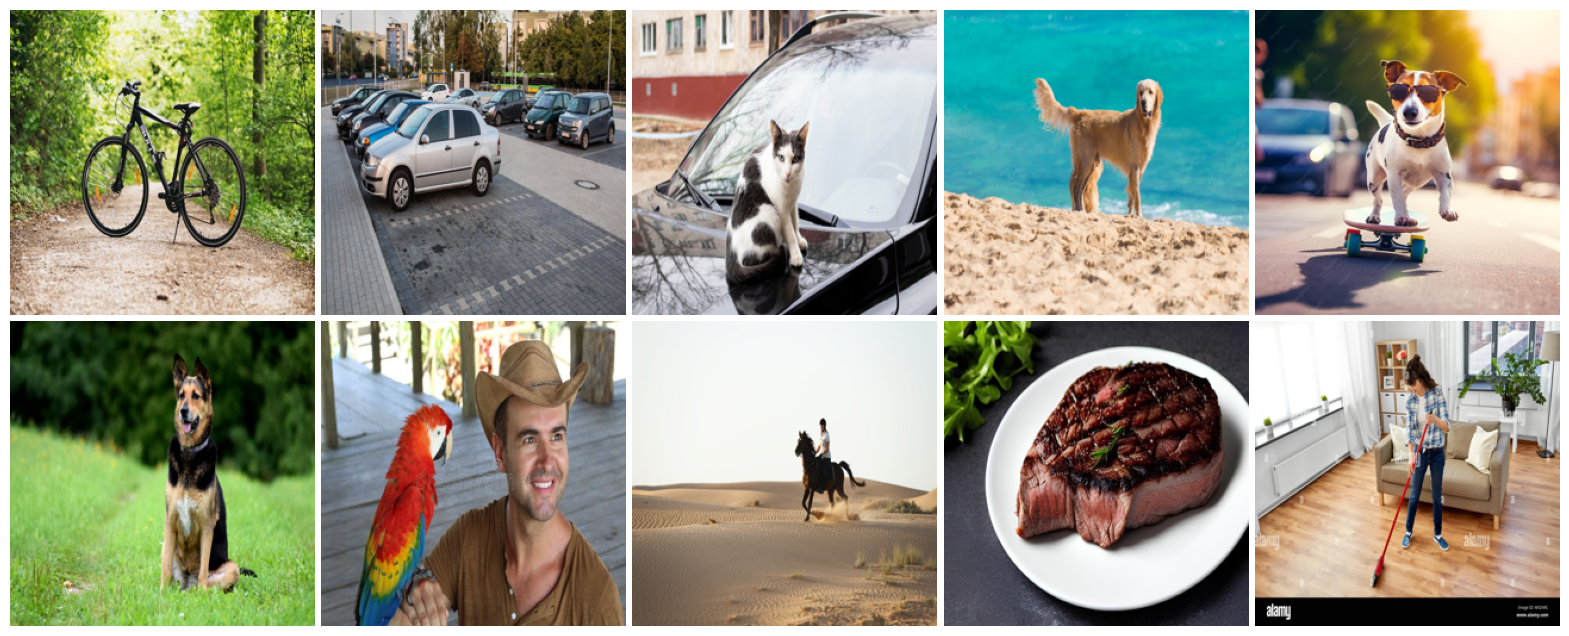

In [10]:
# Visualize the images in a grid
from PIL import Image
import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(selected_files) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, fname in enumerate(selected_files):
    img = Image.open(os.path.join(custom_dir, fname)).convert('RGB').resize((256, 256))
    axes[i].imshow(img)
    axes[i].axis('off')

for j in range(len(selected_files), len(axes)):
    axes[j].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

## Analiza: wygenerowane opisy i mapy uwagi

Dla każdego obrazu model generuje opis słowo po słowie. Pod każdym słowem widoczna
jest mapa uwagi - jaśniejszy region = wyższa waga przy wyborze tego słowa.

Interesują nas dwa pytania:
1. Czy opis jest semantycznie poprawny?
2. Czy mapa uwagi wskazuje właściwy obiekt dla każdego słowa?

Analyzing 10 custom samples...


SOURCE: bike-in-the-forest.jpg
RESULT: a bike parked on top of a dirt road


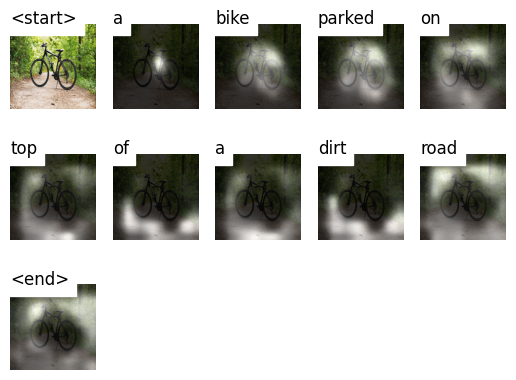


SOURCE: cars-in-a-parking-lot.jpg
RESULT: a car is parked in a parking lot


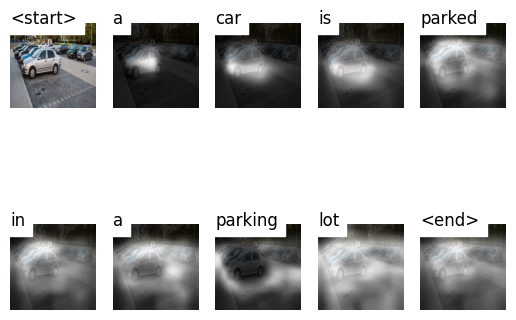


SOURCE: cat-on-a-car.jpg
RESULT: a cat sitting on the hood of a car


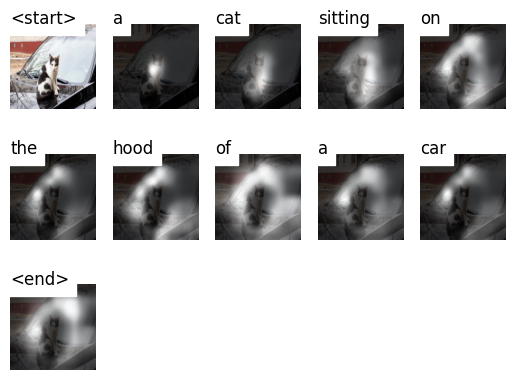


SOURCE: dog-on-a-beach.jpg
RESULT: a white dog standing on top of a sandy beach


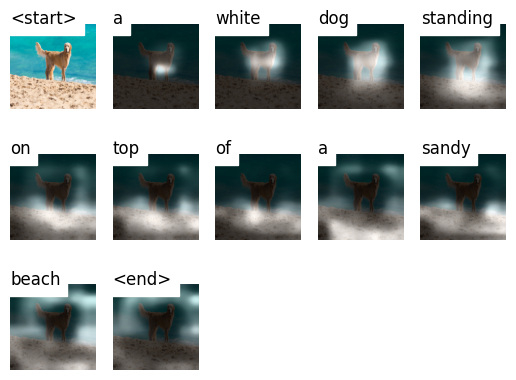


SOURCE: dog-on-a-skateboard.jpg
RESULT: a small dog is riding on a skateboard


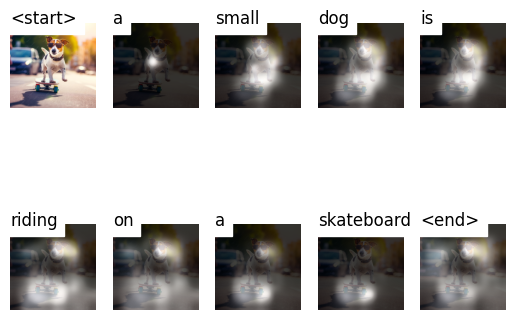


SOURCE: dog-on-grass.jpg
RESULT: a dog sitting in a field of grass


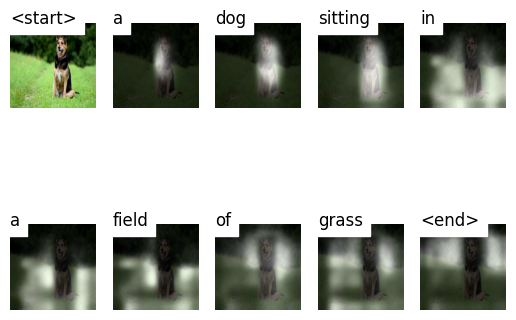


SOURCE: guy-with-parrot.jpg
RESULT: a man is holding a parrot on his head


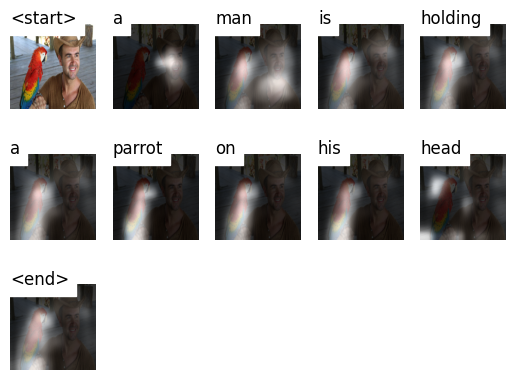


SOURCE: horse-riding-through-the-desert.jpg
RESULT: a person riding a horse on a beach


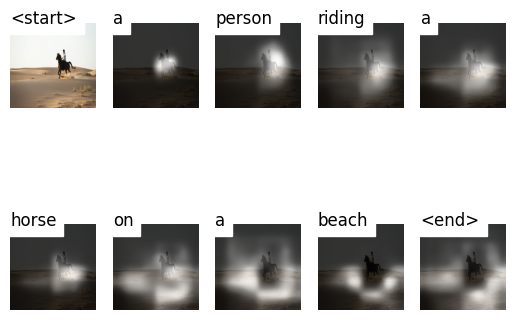


SOURCE: steak-on-a-plate.jpg
RESULT: a piece of chocolate cake on a white plate


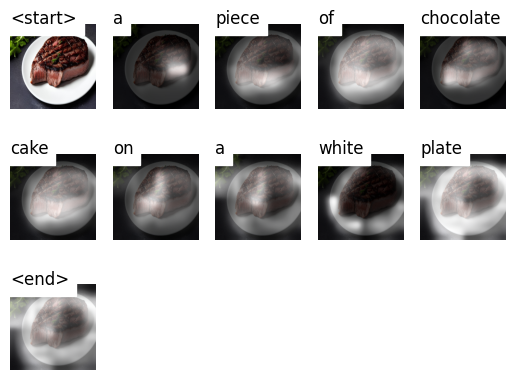


SOURCE: woman-with-broom.jpg
RESULT: a woman is playing a video game in a living room


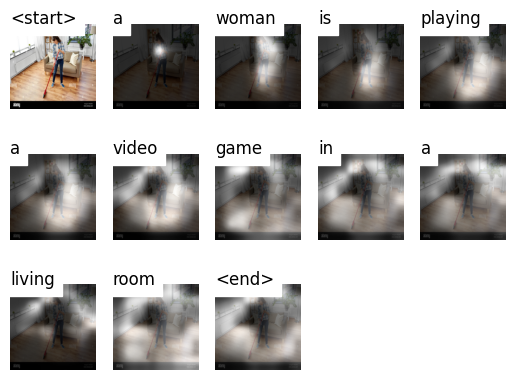

In [11]:
def run_custom_attention_analysis(image_list, k=5):
    """
    Performs qualitative attention analysis on custom images.
    Visualizes how the model grounds linguistic tokens in visual regions.
    """
    print(f"Analyzing {len(image_list)} custom samples...\n")
    
    for filename in image_list:
        fpath = os.path.join(custom_dir, filename)
        
        if not os.path.exists(fpath):
            print(f"Skipping: {filename} (File not found at {fpath})")
            continue
            
        # Inference
        seq, alphas = caption_image_beam_search(encoder, decoder, fpath, word_map, k)
        
        # Sentence reconstruction
        caption = [rev_word_map[i] for i in seq if i not in 
                   {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        print(f"\n{'='*50}")
        print(f"SOURCE: {filename}")
        print(f"RESULT: {' '.join(caption)}")
        print(f"{'='*50}")
        
        # Attention visualization
        alphas_tensor = torch.FloatTensor(alphas)
        visualize_att(fpath, seq, alphas_tensor, rev_word_map, smooth=True)

# Run visualization
run_custom_attention_analysis(selected_files)

## Wnioski

**Przypadki poprawne** (model rozpoznaje właściwe obiekty):
- `dog-on-a-beach.jpg` -> *"a white dog standing on top of a sandy beach"* - uwaga
  przesuwa się od psa do piasku zgodnie z generowanymi słowami
- `dog-on-a-skateboard.jpg` -> *"a small dog is riding on a skateboard"* - model
  poprawnie identyfikuje zarówno psa jak i deskorolkę
- `dog-on-grass.jpg` -> *"a dog sitting in a field of grass"* - poprawne
- `bike-in-the-forest.jpg` -> *"a bike parked on top of a dirt road"* - poprawne
- `cars-in-a-parking-lot.jpg` -> *"a car is parked in a parking lot"* - poprawne
- `cat-on-a-car.jpg` -> *"a cat sitting on the hood of a car"* - poprawne

**Przypadki błędów atrybutów** (obiekt rozpoznany, ale cecha błędna):
- `guy-with-parrot.jpg` -> *"a man is holding a parrot on his head"* - model
  poprawnie rozpoznał mężczyznę i papugę, ale błędnie określił relację przestrzenną:
  papuga siedzi na barku, nie na głowie

**Przypadki halucynacji** (model myli obiekty):
- `steak-on-a-plate.jpg` -> *"a piece of chocolate cake on a white plate"* - stek
  pomylony z ciastem czekoladowym (podobna brązowa, nieregularna forma)
- `horse-riding-through-the-desert.jpg` -> *"a person riding a horse on a beach"* -
  pustynia pomylona z plażą (piasek, brak roślinności - zbliżone cechy wizualne)
- `woman-with-broom.jpg` -> *"a woman is playing a video game in a living room"* -
  kobieta zamiatająca podłogę opisana jako grająca w grę wideo; model zignorował
  miotłę i oparł się na kontekście pomieszczenia

**Kluczowa obserwacja:**
Model radzi sobie dobrze z obiektami częstymi w MS COCO i prostymi scenami
(psy, rowery, samochody, koty). 

Kobieta z miotłą jest interesującym przypadkiem: model całkowicie zignorował miotłę
i sklasyfikował scenę na podstawie samego tła (salon), co sugeruje że kontekst
sceny może czasami dominować nad lokalnymi cechami obiektów.